<a href="https://colab.research.google.com/github/silviaparente/computational_astrobiology/blob/main/Copia_di_NASA_Exoplanet_Archive_Gradients_GD_ML_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NASA Exoplanet Archive: Gradients, Gradient Descent, and Machine Learning

This Google Colab notebook demonstrates **real gradient-based machine learning** using **real exoplanet data** from the NASA Exoplanet Archive.

The goal is to show the mathematical chain:

\[
\text{prediction} \rightarrow \text{loss} \rightarrow \text{gradient} \rightarrow \text{parameter update}
\]

We will implement from scratch:

1. Linear regression with explicit gradients.
2. Manual gradient descent.
3. Gradient checking with finite differences.
4. Logistic regression with explicit gradients.
5. A visual decision boundary.
6. Comparison with standard `scikit-learn` models.

## 1. Import libraries

The gradient descent models are implemented manually with `numpy`.

We use `scikit-learn` only for:
- train/test splitting,
- standardization,
- comparison with standard implementations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import quote
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LinearRegression, LogisticRegression

np.random.seed(42)

## 2. Download real NASA Exoplanet Archive data

We query the NASA Exoplanet Archive TAP service.

We use the composite planetary parameters table `pscomppars`.

The selected columns include:

- `pl_orbper`: orbital period in days
- `pl_rade`: planet radius in Earth radii
- `pl_bmasse`: planet mass in Earth masses
- `st_teff`: stellar effective temperature
- `st_rad`: stellar radius
- `st_mass`: stellar mass
- `sy_dist`: system distance in parsecs

In [2]:
query = """
SELECT
    pl_name,
    pl_orbper,
    pl_rade,
    pl_bmasse,
    pl_eqt,
    st_teff,
    st_rad,
    st_mass,
    sy_dist,
    discoverymethod
FROM pscomppars
WHERE
    pl_orbper IS NOT NULL
    AND pl_rade IS NOT NULL
    AND pl_bmasse IS NOT NULL
    AND st_teff IS NOT NULL
    AND st_rad IS NOT NULL
    AND st_mass IS NOT NULL
    AND sy_dist IS NOT NULL
"""

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=" + quote(query) + "&format=csv"

df = pd.read_csv(url)
df.head()

,pl_name,pl_orbper,pl_rade,pl_bmasse,pl_eqt,st_teff,st_rad,st_mass,sy_dist,discoverymethod
0,Kepler-1167 b,1.003934,1.710000,3.570,1419.0,4971.0,0.750,0.790,820.905,Transit
1,Kepler-1740 b,8.172400,3.323214,11.000,858.0,5705.0,0.905,0.943,1061.770,Transit
2,Kepler-1581 b,6.283855,0.800000,0.437,1108.0,6022.0,1.230,1.120,493.175,Transit
3,Kepler-644 b,3.173917,3.150000,10.100,1655.0,6747.0,1.810,1.490,1318.050,Transit
4,Kepler-1752 b,56.358501,4.540605,18.700,419.0,5446.0,0.821,0.824,962.888,Transit


In [3]:
print("Number of rows:", len(df))
display(df.head())
display(df.describe())

Number of rows: 5832


,pl_name,pl_orbper,pl_rade,pl_bmasse,pl_eqt,st_teff,st_rad,st_mass,sy_dist,discoverymethod
0,Kepler-1167 b,1.003934,1.710000,3.570,1419.0,4971.0,0.750,0.790,820.905,Transit
1,Kepler-1740 b,8.172400,3.323214,11.000,858.0,5705.0,0.905,0.943,1061.770,Transit
2,Kepler-1581 b,6.283855,0.800000,0.437,1108.0,6022.0,1.230,1.120,493.175,Transit
3,Kepler-644 b,3.173917,3.150000,10.100,1655.0,6747.0,1.810,1.490,1318.050,Transit
4,Kepler-1752 b,56.358501,4.540605,18.700,419.0,5446.0,0.821,0.824,962.888,Transit


,pl_orbper,pl_rade,pl_bmasse,pl_eqt,st_teff,st_rad,st_mass,sy_dist
count,5.832000e+03,5832.000000,5832.000000,4586.000000,5832.000000,5832.000000,5832.000000,5832.000000
mean,7.067626e+04,5.443665,312.816690,907.469416,5370.308184,1.497928,0.957062,482.954278
std,5.264864e+06,5.065181,949.655488,453.124580,1333.160837,3.920804,0.348911,466.702870
min,1.120067e-01,0.309800,0.036400,55.900000,2375.000000,0.011500,0.016000,1.301190
25%,4.313090e+00,1.780000,4.055000,568.325000,4912.000000,0.770000,0.800000,97.237325
50%,1.066029e+01,2.720000,8.500000,817.500000,5550.000000,0.950000,0.950000,340.828000
75%,3.701275e+01,10.572552,123.238582,1156.750000,5897.490000,1.240000,1.094173,762.596000
max,4.020000e+08,25.000000,9333.031172,4050.000000,40000.000000,88.475000,8.760000,3460.510000


## 3. Clean the data and create logarithmic variables

Exoplanet properties span many orders of magnitude.

Therefore, we work with logarithms:

\[
x_{\log}=\log_{10}(x)
\]

This makes the regression and optimization numerically more stable.

In [4]:
positive_cols = ["pl_orbper", "pl_rade", "pl_bmasse", "st_teff", "st_rad", "st_mass", "sy_dist"]

for col in positive_cols:
    df = df[df[col] > 0]

df["log_orbper"] = np.log10(df["pl_orbper"])
df["log_rade"] = np.log10(df["pl_rade"])
df["log_bmasse"] = np.log10(df["pl_bmasse"])
df["log_st_teff"] = np.log10(df["st_teff"])
df["log_st_rad"] = np.log10(df["st_rad"])
df["log_st_mass"] = np.log10(df["st_mass"])
df["log_dist"] = np.log10(df["sy_dist"])

df = df.dropna().reset_index(drop=True)

print("Cleaned rows:", len(df))
display(df[["pl_name", "pl_orbper", "pl_rade", "pl_bmasse", "st_teff", "st_rad", "st_mass", "sy_dist"]].head())

Cleaned rows: 4586


,pl_name,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,sy_dist
0,Kepler-1167 b,1.003934,1.710000,3.570,4971.0,0.750,0.790,820.905
1,Kepler-1740 b,8.172400,3.323214,11.000,5705.0,0.905,0.943,1061.770
2,Kepler-1581 b,6.283855,0.800000,0.437,6022.0,1.230,1.120,493.175
3,Kepler-644 b,3.173917,3.150000,10.100,6747.0,1.810,1.490,1318.050
4,Kepler-1752 b,56.358501,4.540605,18.700,5446.0,0.821,0.824,962.888


## 4. Visualize the period-radius plane

This gives a first look at the real exoplanet population.

The data are affected by astrophysics, detection limits, observational bias, and heterogeneous literature sources.

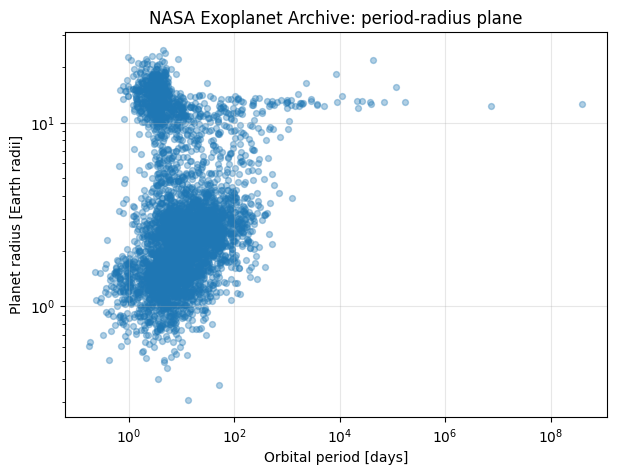

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(df["pl_orbper"], df["pl_rade"], alpha=0.35, s=18)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Orbital period [days]")
plt.ylabel("Planet radius [Earth radii]")
plt.title("NASA Exoplanet Archive: period-radius plane")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Regression task

We predict:

\[
y = \log_{10}(R_p/R_\oplus)
\]

from:

\[
x =
[
\log_{10}P,
\log_{10}M_p,
\log_{10}T_{\star},
\log_{10}R_{\star},
\log_{10}M_{\star},
\log_{10}d
]
\]

This is a statistical demonstration, not a physical causal model.

In [6]:
feature_cols = ["log_orbper", "log_bmasse", "log_st_teff", "log_st_rad", "log_st_mass", "log_dist"]
target_col = "log_rade"

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

print("Training matrix shape:", X_train_s.shape)
print("Training target shape:", y_train_s.shape)

Training matrix shape: (3439, 6)
Training target shape: (3439, 1)


## 6. Linear regression from scratch

The model is:

\[
\hat{y}=Xw+b
\]

For one object:

\[
\hat{y}_i = \sum_{j=1}^{d} X_{ij}w_j+b
\]

The mean squared error is:

\[
L(w,b)
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
\]

Define residual:

\[
r_i=\hat{y}_i-y_i
\]

Then:

\[
L=\frac{1}{N}\sum_i r_i^2
\]

## 7. Derive the gradient for linear regression

For one weight \(w_k\):

\[
\frac{\partial L}{\partial w_k}
=
\frac{\partial}{\partial w_k}
\left[
\frac{1}{N}\sum_{i=1}^{N}r_i^2
\right]
\]

Using the chain rule:

\[
\frac{\partial L}{\partial w_k}
=
\frac{1}{N}\sum_{i=1}^{N}
2r_i
\frac{\partial r_i}{\partial w_k}
\]

Since:

\[
r_i=\sum_jX_{ij}w_j+b-y_i
\]

we have:

\[
\frac{\partial r_i}{\partial w_k}=X_{ik}
\]

Therefore:

\[
\frac{\partial L}{\partial w_k}
=
\frac{2}{N}\sum_{i=1}^{N}r_iX_{ik}
\]

Vector form:

\[
\nabla_wL=\frac{2}{N}X^T(\hat{y}-y)
\]

Bias gradient:

\[
\frac{\partial L}{\partial b}
=
\frac{2}{N}\sum_i(\hat{y}_i-y_i)
\]

In [7]:
def mse_loss(y_hat, y):
    return np.mean((y_hat - y) ** 2)

def linear_forward(X, w, b):
    return X @ w + b

def linear_gradients(X, y, w, b):
    N = X.shape[0]
    y_hat = linear_forward(X, w, b)
    residual = y_hat - y

    loss = mse_loss(y_hat, y)
    grad_w = (2 / N) * X.T @ residual
    grad_b = (2 / N) * np.sum(residual)

    return loss, grad_w, grad_b

## 8. Manual gradient descent

Gradient descent updates parameters by:

\[
w \leftarrow w-\eta\nabla_wL
\]

\[
b \leftarrow b-\eta\frac{\partial L}{\partial b}
\]

where \(\eta\) is the learning rate.

Visual interpretation:

```text
current parameters → compute loss → compute gradient → move downhill
```

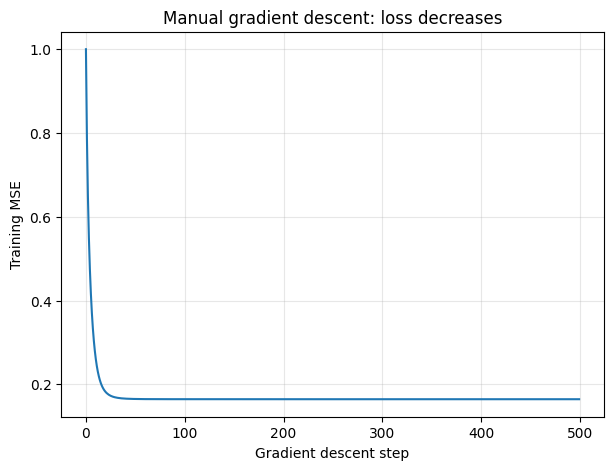

Final training loss: 0.1642962494091251


In [8]:
n_features = X_train_s.shape[1]

w = np.zeros((n_features, 1))
b = 0.0

learning_rate = 0.05
n_steps = 500

loss_history = []

for step in range(n_steps):
    loss, grad_w, grad_b = linear_gradients(X_train_s, y_train_s, w, b)

    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    loss_history.append(loss)

plt.figure(figsize=(7, 5))
plt.plot(loss_history)
plt.xlabel("Gradient descent step")
plt.ylabel("Training MSE")
plt.title("Manual gradient descent: loss decreases")
plt.grid(True, alpha=0.3)
plt.show()

print("Final training loss:", loss_history[-1])

## 9. Interpret the learned linear parameters

Because we standardized the features, the absolute value of a weight approximately measures how strongly that standardized feature influences the prediction.

In [9]:
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "manual_gradient_descent_weight": w.flatten()
}).sort_values("manual_gradient_descent_weight", key=np.abs, ascending=False)

display(coef_table)

,feature,manual_gradient_descent_weight
1,log_bmasse,0.875712
3,log_st_rad,0.128403
2,log_st_teff,-0.042467
5,log_dist,-0.016618
0,log_orbper,-0.003763
4,log_st_mass,0.001160


Manual gradient descent test MSE: 0.021260760283454302
Manual gradient descent test R2: 0.8395876953520439


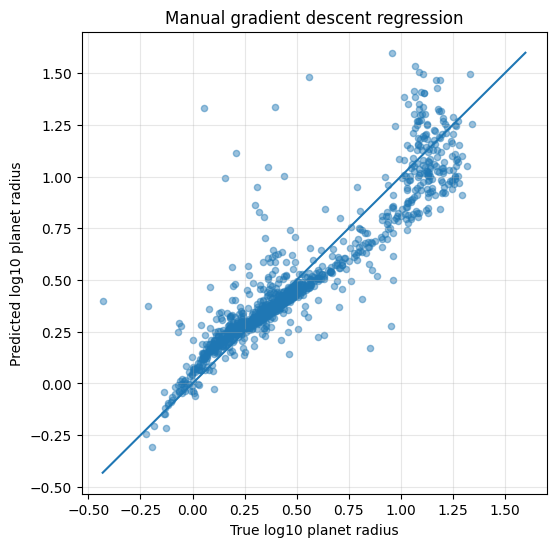

In [10]:
y_pred_test_s = linear_forward(X_test_s, w, b)
y_pred_test = scaler_y.inverse_transform(y_pred_test_s)
y_test_original = scaler_y.inverse_transform(y_test_s)

print("Manual gradient descent test MSE:", mean_squared_error(y_test_original, y_pred_test))
print("Manual gradient descent test R2:", r2_score(y_test_original, y_pred_test))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_original, y_pred_test, alpha=0.45, s=20)
lims = [
    min(y_test_original.min(), y_pred_test.min()),
    max(y_test_original.max(), y_pred_test.max())
]
plt.plot(lims, lims)
plt.xlabel("True log10 planet radius")
plt.ylabel("Predicted log10 planet radius")
plt.title("Manual gradient descent regression")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Compare with scikit-learn linear regression

This is a sanity check.

The manual gradient descent solution should be close to the standard linear regression solution.

In [11]:
lr = LinearRegression()
lr.fit(X_train_s, y_train_s.ravel())

y_pred_sklearn_s = lr.predict(X_test_s).reshape(-1, 1)
y_pred_sklearn = scaler_y.inverse_transform(y_pred_sklearn_s)

print("Sklearn test MSE:", mean_squared_error(y_test_original, y_pred_sklearn))
print("Sklearn test R2:", r2_score(y_test_original, y_pred_sklearn))

display(pd.DataFrame({
    "feature": feature_cols,
    "manual_GD_weight": w.flatten(),
    "sklearn_weight": lr.coef_.flatten()
}))

Sklearn test MSE: 0.021264745285890476
Sklearn test R2: 0.8395576285333464


,feature,manual_GD_weight,sklearn_weight
0,log_orbper,-0.003763,-0.003802
1,log_bmasse,0.875712,0.875701
2,log_st_teff,-0.042467,-0.041538
3,log_st_rad,0.128403,0.129917
4,log_st_mass,0.001160,-0.001248
5,log_dist,-0.016618,-0.016586


## 11. Gradient checking

Numerical finite-difference gradient:

\[
\frac{\partial L}{\partial w_k}
\approx
\frac{L(w_k+\epsilon)-L(w_k-\epsilon)}{2\epsilon}
\]

Analytic gradient:

\[
\frac{\partial L}{\partial w_k}
=
\frac{2}{N}\sum_i r_iX_{ik}
\]

If these are close, our derivative is correct.

In [12]:
k = 0
epsilon = 1e-5

loss, grad_w, grad_b = linear_gradients(X_train_s, y_train_s, w, b)

w_plus = w.copy()
w_minus = w.copy()

w_plus[k, 0] += epsilon
w_minus[k, 0] -= epsilon

loss_plus = mse_loss(linear_forward(X_train_s, w_plus, b), y_train_s)
loss_minus = mse_loss(linear_forward(X_train_s, w_minus, b), y_train_s)

numeric_grad = (loss_plus - loss_minus) / (2 * epsilon)
analytic_grad = grad_w[k, 0]

print("Feature checked:", feature_cols[k])
print("Analytic gradient:", analytic_grad)
print("Numerical gradient:", numeric_grad)
print("Absolute difference:", abs(analytic_grad - numeric_grad))

Feature checked: log_orbper
Analytic gradient: 3.7990116093346234e-06
Numerical gradient: 3.7990111056984684e-06
Absolute difference: 5.036361550141155e-13


## 12. Binary classification task

Define:

\[
\text{large planet} =
\begin{cases}
1, & R_p>4R_\oplus\\
0, & R_p\le4R_\oplus
\end{cases}
\]

We now learn:

\[
p(y=1|x)=\sigma(Xw+b)
\]

In [13]:
df["large_planet"] = (df["pl_rade"] > 4.0).astype(int)

X_cls = df[feature_cols].values
y_cls = df["large_planet"].values.reshape(-1, 1)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
Xc_train_s = scaler_cls.fit_transform(Xc_train)
Xc_test_s = scaler_cls.transform(Xc_test)

print("Class balance:")
display(df["large_planet"].value_counts(normalize=True))

Class balance:


,proportion
large_planet,
0,0.742477
1,0.257523


## 13. Logistic regression model

Model:

\[
z=Xw+b
\]

\[
p=\sigma(z)=\frac{1}{1+e^{-z}}
\]

Binary cross-entropy loss:

\[
L
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
\]

## 14. Derive logistic regression gradient

For one object:

\[
L_i=-\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
\]

Derivative with respect to \(p_i\):

\[
\frac{\partial L_i}{\partial p_i}
=
-\left[
\frac{y_i}{p_i}
-
\frac{1-y_i}{1-p_i}
\right]
\]

Common denominator:

\[
\frac{\partial L_i}{\partial p_i}
=
\frac{p_i-y_i}{p_i(1-p_i)}
\]

Since:

\[
p_i=\sigma(z_i)
\]

and:

\[
\frac{\partial p_i}{\partial z_i}=p_i(1-p_i)
\]

we get:

\[
\frac{\partial L_i}{\partial z_i}
=
\frac{p_i-y_i}{p_i(1-p_i)}
p_i(1-p_i)
=
p_i-y_i
\]

Therefore:

\[
\nabla_wL=\frac{1}{N}X^T(p-y)
\]

\[
\frac{\partial L}{\partial b}
=
\frac{1}{N}\sum_i(p_i-y_i)
\]

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(p, y):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def logistic_forward(X, w, b):
    return sigmoid(X @ w + b)

def logistic_gradients(X, y, w, b):
    N = X.shape[0]
    p = logistic_forward(X, w, b)
    loss = binary_cross_entropy(p, y)
    residual = p - y

    grad_w = (1 / N) * X.T @ residual
    grad_b = (1 / N) * np.sum(residual)

    return loss, grad_w, grad_b, p

## 15. Train logistic regression manually

Update rules:

\[
w \leftarrow w-\eta\frac{1}{N}X^T(p-y)
\]

\[
b \leftarrow b-\eta\frac{1}{N}\sum_i(p_i-y_i)
\]

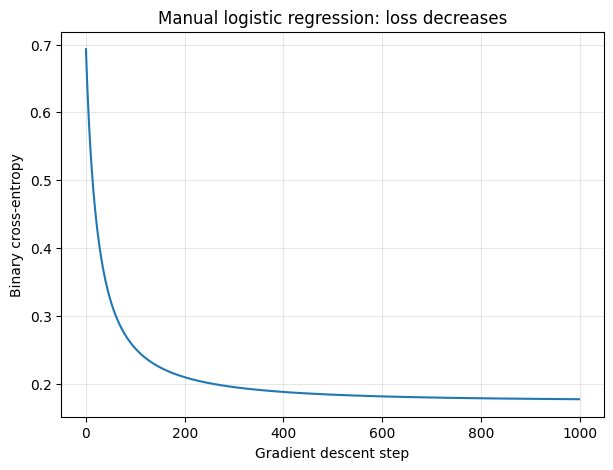

Final training loss: 0.1769906986937917


In [15]:
n_features = Xc_train_s.shape[1]

w_log = np.zeros((n_features, 1))
b_log = 0.0

learning_rate = 0.1
n_steps = 1000

log_loss_history = []

for step in range(n_steps):
    loss, grad_w, grad_b, p_train = logistic_gradients(Xc_train_s, yc_train, w_log, b_log)

    w_log -= learning_rate * grad_w
    b_log -= learning_rate * grad_b

    log_loss_history.append(loss)

plt.figure(figsize=(7, 5))
plt.plot(log_loss_history)
plt.xlabel("Gradient descent step")
plt.ylabel("Binary cross-entropy")
plt.title("Manual logistic regression: loss decreases")
plt.grid(True, alpha=0.3)
plt.show()

print("Final training loss:", log_loss_history[-1])

In [16]:
p_test = logistic_forward(Xc_test_s, w_log, b_log)
y_pred_cls = (p_test >= 0.5).astype(int)

print("Manual logistic regression accuracy:", accuracy_score(yc_test, y_pred_cls))
print("Confusion matrix:")
print(confusion_matrix(yc_test, y_pred_cls))
print(classification_report(yc_test, y_pred_cls, target_names=["small/medium", "large"]))

Manual logistic regression accuracy: 0.9311246730601569
Confusion matrix:
[[831  21]
 [ 58 237]]
              precision    recall  f1-score   support

small/medium       0.93      0.98      0.95       852
       large       0.92      0.80      0.86       295

    accuracy                           0.93      1147
   macro avg       0.93      0.89      0.91      1147
weighted avg       0.93      0.93      0.93      1147



## 16. Interpret logistic regression weights

For logistic regression:

\[
p=\sigma(w^Tx+b)
\]

The log-odds are:

\[
\log\frac{p}{1-p}=w^Tx+b
\]

So each weight tells us how a standardized feature changes the log-odds of being a large planet.

In [17]:
log_coef_table = pd.DataFrame({
    "feature": feature_cols,
    "manual_logistic_weight": w_log.flatten()
}).sort_values("manual_logistic_weight", key=np.abs, ascending=False)

display(log_coef_table)

,feature,manual_logistic_weight
1,log_bmasse,3.330163
3,log_st_rad,0.492526
4,log_st_mass,0.217979
5,log_dist,-0.211151
2,log_st_teff,-0.192668
0,log_orbper,0.112983


## 17. Compare with scikit-learn logistic regression

In [18]:
sk_log = LogisticRegression(max_iter=5000)
sk_log.fit(Xc_train_s, yc_train.ravel())

sk_pred = sk_log.predict(Xc_test_s)

print("Sklearn logistic regression accuracy:", accuracy_score(yc_test, sk_pred))
print("Confusion matrix:")
print(confusion_matrix(yc_test, sk_pred))

display(pd.DataFrame({
    "feature": feature_cols,
    "manual_logistic_weight": w_log.flatten(),
    "sklearn_logistic_weight": sk_log.coef_.flatten()
}))

Sklearn logistic regression accuracy: 0.9319965126416739
Confusion matrix:
[[830  22]
 [ 56 239]]


,feature,manual_logistic_weight,sklearn_logistic_weight
0,log_orbper,0.112983,0.217218
1,log_bmasse,3.330163,3.720392
2,log_st_teff,-0.192668,-0.440416
3,log_st_rad,0.492526,0.546913
4,log_st_mass,0.217979,0.429443
5,log_dist,-0.211151,-0.205815


## 18. Visual decision boundary

Use only two features for plotting:

\[
x_1=\log_{10}P
\]

\[
x_2=\log_{10}M_p
\]

The logistic boundary is where:

\[
p=0.5
\]

Since:

\[
\sigma(z)=0.5 \Longleftrightarrow z=0
\]

the boundary satisfies:

\[
w_1x_1+w_2x_2+b=0
\]

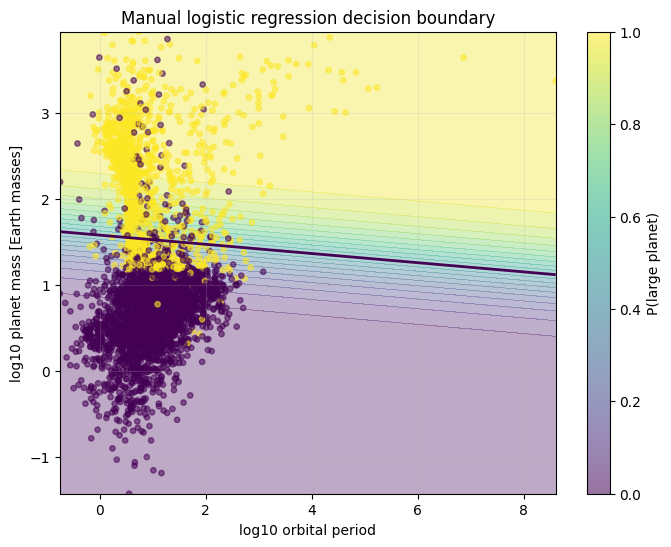

In [19]:
X2 = df[["log_orbper", "log_bmasse"]].values
y2 = df["large_planet"].values.reshape(-1, 1)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2
)

scaler_2 = StandardScaler()
X2_train_s = scaler_2.fit_transform(X2_train)
X2_test_s = scaler_2.transform(X2_test)

w2 = np.zeros((2, 1))
b2 = 0.0

for step in range(1000):
    loss, grad_w, grad_b, _ = logistic_gradients(X2_train_s, y2_train, w2, b2)
    w2 -= 0.1 * grad_w
    b2 -= 0.1 * grad_b

x_min, x_max = X2[:, 0].min(), X2[:, 0].max()
y_min, y_max = X2[:, 1].min(), X2[:, 1].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_original = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler_2.transform(grid_original)
probs = logistic_forward(grid_scaled, w2, b2).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, probs, levels=20, alpha=0.35)
plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)
plt.scatter(X2[:, 0], X2[:, 1], c=y2.ravel(), s=15, alpha=0.55)
plt.xlabel("log10 orbital period")
plt.ylabel("log10 planet mass [Earth masses]")
plt.title("Manual logistic regression decision boundary")
plt.colorbar(label="P(large planet)")
plt.grid(True, alpha=0.2)
plt.show()

## 19. Why standardization matters

For linear regression:

\[
\nabla_wL=\frac{2}{N}X^T(\hat{y}-y)
\]

If one column of \(X\) has very large values, its gradient can dominate the update.

Standardization:

\[
x_{\mathrm{std}}=\frac{x-\mu}{\sigma}
\]

makes features comparable in scale.

In [20]:
raw_scales = pd.DataFrame({
    "feature": feature_cols,
    "raw_mean": X.mean(axis=0),
    "raw_std": X.std(axis=0),
    "standardized_mean": X_train_s.mean(axis=0),
    "standardized_std": X_train_s.std(axis=0)
})

display(raw_scales)

,feature,raw_mean,raw_std,standardized_mean,standardized_std
0,log_orbper,0.990622,0.609773,8.602049e-16,1.0
1,log_bmasse,1.081414,0.845613,1.377949e-15,1.0
2,log_st_teff,3.724144,0.075365,1.967126e-13,1.0
3,log_st_rad,-0.035227,0.190135,1.231996e-15,1.0
4,log_st_mass,-0.055594,0.165566,-7.195788e-16,1.0
5,log_dist,2.543144,0.522927,3.287022e-15,1.0


## 20. Summary

The whole learning loop is:

```text
forward pass → compute loss → compute gradients → update parameters
```

For a dense layer:

\[
z=Wx+b
\]

with upstream gradient:

\[
g_z=\frac{\partial L}{\partial z}
\]

the backward rules are:

\[
\nabla_WL=g_zx^T
\]

\[
\nabla_xL=W^Tg_z
\]

\[
\nabla_bL=g_z
\]

For linear regression:

\[
g_z=\frac{2}{N}(\hat{y}-y)
\]

For logistic regression with cross-entropy:

\[
g_z=\frac{1}{N}(p-y)
\]

The universal update rule is:

\[
\theta\leftarrow\theta-\eta\nabla_\theta L
\]

Main message:

> Gradient descent turns mistakes into parameter updates.

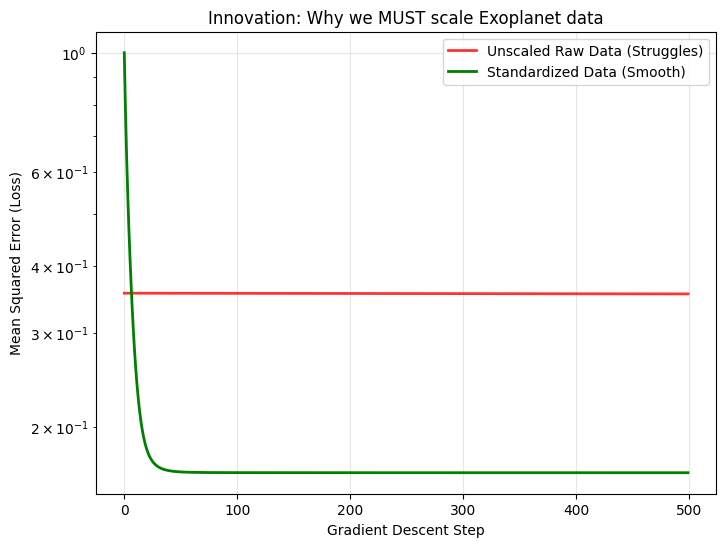

Observation: The green line (scaled data) drops quickly and smoothly finds the bottom of the error curve.
The red line (unscaled data) stays high and struggles because the large raw numbers (like distance in parsecs) create chaotic, unbalanced gradients.


In [21]:
# --- INNOVATION: Visualizing Why Standardization Matters ---
# This block visually compares the loss curve of Gradient Descent with and without scaled data.
# It proves why scaling exoplanet data is just as important as the math itself.

import matplotlib.pyplot as plt
import numpy as np

# 1. Try to train on RAW, unscaled data
# (We have to use a tiny learning rate so the gradients don't immediately explode to infinity)
w_raw = np.zeros((n_features, 1))
b_raw = 0.0
lr_raw = 1e-7
raw_loss_history = []

for step in range(500):
    # Using the linear_gradients function we wrote in Part 7
    loss, grad_w, grad_b = linear_gradients(X_train, y_train, w_raw, b_raw)
    w_raw -= lr_raw * grad_w
    b_raw -= lr_raw * grad_b
    raw_loss_history.append(loss)

# 2. Plot the raw loss vs the scaled loss (loss_history is already saved from Part 8)
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(raw_loss_history, color='red', label='Unscaled Raw Data (Struggles)', alpha=0.8, linewidth=2)
ax.plot(loss_history, color='green', label='Standardized Data (Smooth)', linewidth=2)

ax.set_xlabel("Gradient Descent Step")
ax.set_ylabel("Mean Squared Error (Loss)")
ax.set_title("Innovation: Why we MUST scale Exoplanet data")
ax.set_yscale('log') # Log scale helps us see the massive difference in errors
ax.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Brief analysis printout
print("Observation: The green line (scaled data) drops quickly and smoothly finds the bottom of the error curve.")
print("The red line (unscaled data) stays high and struggles because the large raw numbers (like distance in parsecs) create chaotic, unbalanced gradients.")